# FINAL — Normalizing Flow / RealNVP

Questo notebook implementa il **Normalizing Flow finale** usando i dataset aggregate creati dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr1_aggregate.npz
```

Il modello è un **RealNVP stabile** addestrato solo su QCD/background,
impara una trasformazione invertibile che porta i dati reali, in questo caso jet QCD, verso una distribuzione semplice, di solito una gaussiana standard.

L’idea è che i jet QCD, essendo usati per il training, dovrebbero avere alta probabilità secondo il modello. Eventi più strani, come possibili Emerging Jets, dovrebbero invece risultare meno probabili e quindi avere uno score di anomalia più alto.

La versione “stabile” serve soprattutto a evitare problemi numerici durante il training. Per questo si usano accorgimenti come clipping o limitazione dei fattori di scala, normalizzazione delle feature, weight decay e controlli su valori `NaN` o infiniti. In questo modo il flow resta invertibile e la likelihood non esplode numericamente.

In sintesi, il RealNVP stabile viene usato per stimare quanto un evento è compatibile con la distribuzione QCD appresa: più la likelihood è bassa, più l’evento è considerato anomalo.
Schema:

```text
bkg_train  -> training QCD
bkg_eval   -> validation QCD + test QCD interno
sig        -> signal EJ
```


Score di anomalia:

```text
score = NLL = -log p(x)
```

dove `x` è il vettore aggregate jet+track.



## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento dataset aggregate

In [2]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks,
# sia se è lanciato dalla root del progetto.

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr1_aggregate.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr1_aggregate.npz. "
        "Controlla che esista in FINAL/processed/repr1_aggregate.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "normalizing_flow"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr1_aggregate.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr1_aggregate.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\normalizing_flow

Keys in repr1_aggregate.npz:
  bkg_train                           shape=(40000, 96) dtype=float32
  bkg_eval                            shape=(40000, 96) dtype=float32
  sig                                 shape=(40000, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32


## 3. Loader robusto delle chiavi

In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


train_key = first_existing_key(
    data,
    [
        "X_agg_bkg_train",
        "bkg_train",
        "X_bkg_train",
        "X_train_background",
        "X_agg_train_background",
        "train_background",
        "X_train",
    ],
)

eval_key = first_existing_key(
    data,
    [
        "X_agg_bkg_eval",
        "bkg_eval",
        "X_bkg_eval",
        "X_eval_background",
        "X_agg_eval_background",
        "eval_background",
        "X_eval",
        "X_val",
    ],
)

test_bkg_key = first_existing_key(
    data,
    [
        "X_agg_bkg_test",
        "bkg_test",
        "X_bkg_test",
        "X_test_background",
        "X_agg_test_background",
        "test_background",
        "X_test_bkg",
    ],
    required=False,
)

sig_key = first_existing_key(
    data,
    [
        "X_agg_sig",
        "sig",
        "X_sig",
        "X_signal",
        "X_test_signal",
        "X_agg_test_signal",
        "test_signal",
    ],
)

feature_key = first_existing_key(
    data,
    [
        "aggregate_feature_names",
        "agg_feature_names",
        "feature_names",
        "X_agg_feature_names",
    ],
    required=False,
)

X_train_raw = np.asarray(data[train_key], dtype=np.float32)
X_eval_raw = np.asarray(data[eval_key], dtype=np.float32)
X_sig_raw = np.asarray(data[sig_key], dtype=np.float32)

if test_bkg_key is not None:
    X_bkg_test_raw = np.asarray(data[test_bkg_key], dtype=np.float32)
    X_val_raw = X_eval_raw
    print("Uso test background separato:", test_bkg_key)
else:
    X_val_raw, X_bkg_test_raw = train_test_split(
        X_eval_raw,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )
    #print("Nessun test background separato trovato: splitto bkg_eval in val/test 50/50.")

if feature_key is not None:
    aggregate_feature_names = [str(x) for x in data[feature_key].tolist()]
else:
    aggregate_feature_names = [f"f{i}" for i in range(X_train_raw.shape[1])]

print("\nSelected keys:")
print("train:", train_key, X_train_raw.shape)
print("eval:", eval_key, X_eval_raw.shape)
print("val:", X_val_raw.shape)
print("bkg_test:", test_bkg_key, X_bkg_test_raw.shape)
print("signal:", sig_key, X_sig_raw.shape)
print("n features:", len(aggregate_feature_names))


Selected keys:
train: bkg_train (40000, 96)
eval: bkg_eval (40000, 96)
val: (20000, 96)
bkg_test: None (20000, 96)
signal: sig (40000, 96)
n features: 96


## 4. Anti-leakage check

In [5]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in aggregate_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input aggregate:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input aggregate.")

Leakage check OK: nessuna feature vietata trovata negli input aggregate.


## 5. Pulizia, robust scaling e clipping

In [6]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_train_raw = finite_array(X_train_raw, "X_train_raw")
X_val_raw = finite_array(X_val_raw, "X_val_raw")
X_bkg_test_raw = finite_array(X_bkg_test_raw, "X_bkg_test_raw")
X_sig_raw = finite_array(X_sig_raw, "X_sig_raw")


class RobustClipScaler:
    def __init__(self, clip_value=8.0, eps=1e-6):
        self.clip_value = clip_value
        self.eps = eps
        self.center = None
        self.scale = None

    def fit(self, X):
        self.center = np.median(X, axis=0, keepdims=True)
        q25 = np.percentile(X, 25, axis=0, keepdims=True)
        q75 = np.percentile(X, 75, axis=0, keepdims=True)
        self.scale = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        Xn = (X - self.center) / self.scale
        Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
        Xn = np.clip(Xn, -self.clip_value, self.clip_value)
        return Xn.astype(np.float32)

    def state_dict(self):
        return {
            "clip_value": float(self.clip_value),
            "eps": float(self.eps),
            "center": self.center.reshape(-1).tolist(),
            "scale": self.scale.reshape(-1).tolist(),
        }


CLIP_VALUE = 8.0

scaler = RobustClipScaler(clip_value=CLIP_VALUE)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_bkg_test = scaler.transform(X_bkg_test_raw)
X_sig = scaler.transform(X_sig_raw)

print("After robust scaling + clipping:")
for name, X in [
    ("train", X_train),
    ("val", X_val),
    ("bkg_test", X_bkg_test),
    ("signal", X_sig),
]:
    print(
        f"{name:10s} shape={X.shape} "
        f"mean={X.mean():.4f} std={X.std():.4f} "
        f"clip_frac={np.mean((X <= -CLIP_VALUE) | (X >= CLIP_VALUE)):.5f}"
    )

input_dim = X_train.shape[1]
print("input_dim:", input_dim)

with open(OUTPUT_DIR / "aggregate_flow_scaler.json", "w") as f:
    json.dump(scaler.state_dict(), f, indent=2)

print("Saved scaler:", OUTPUT_DIR / "aggregate_flow_scaler.json")

After robust scaling + clipping:
train      shape=(40000, 96) mean=0.0187 std=1.1448 clip_frac=0.00941
val        shape=(20000, 96) mean=0.0183 std=1.1440 clip_frac=0.00942
bkg_test   shape=(20000, 96) mean=0.0156 std=1.1429 clip_frac=0.00940
signal     shape=(40000, 96) mean=-0.0520 std=1.6764 clip_frac=0.02471
input_dim: 96
Saved scaler: ..\outputs\normalizing_flow\aggregate_flow_scaler.json


## 6. Dataset e DataLoader

In [7]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(
    AggregateDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    AggregateDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 40
Val batches: 20


## 7. Modello RealNVP stabile

In [ ]:
class CouplingNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim),
        )

        # Inizializzazione identità: il flow parte quasi come z=x
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        # La maschera decide quali feature restano fisse e quali vengono trasformate
        self.register_buffer("mask", mask.bool())
        self.scale_clip = scale_clip

        self.active_idx = torch.where(self.mask)[0]
        self.passive_idx = torch.where(~self.mask)[0]

        input_dim = int(self.mask.sum().item())
        output_dim = dim - input_dim
# Due reti separate: una predice la scala, l'altra la traslazione
        self.s_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)
        self.t_net = CouplingNetwork(input_dim, output_dim, hidden_dim=hidden_dim)

    def forward(self, x):
        x_active = x[:, self.active_idx]
        x_passive = x[:, self.passive_idx]

        s = self.s_net(x_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(x_active)

        z = x.clone()
        z_passive = x_passive * torch.exp(s) + t
        z[:, self.passive_idx] = z_passive

        log_det = s.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        # Operazione inversa della trasformazione precedente
        z_active = z[:, self.active_idx]
        z_passive = z[:, self.passive_idx]

        s = self.s_net(z_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)

        t = self.t_net(z_active)

        x = z.clone()
        x_passive = (z_passive - t) * torch.exp(-s)
        x[:, self.passive_idx] = x_passive

        log_det = -s.sum(dim=1)

        return x, log_det


class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
# Permuto le feature tra un coupling layer e il successivo,così nel tempo tutte le variabili possono influenzarsi tra loro
        perm = torch.randperm(dim)
        inv_perm = torch.argsort(perm)

        self.register_buffer("perm", perm)
        self.register_buffer("inv_perm", inv_perm)

    def forward(self, x):
        return x[:, self.perm], torch.zeros(x.shape[0], device=x.device)

    def inverse(self, z):
        return z[:, self.inv_perm], torch.zeros(z.shape[0], device=z.device)


class RealNVPStable(nn.Module):
    def __init__(self, dim, n_layers=8, hidden_dim=256, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        self.n_layers = n_layers

        layers = []

        for i in range(n_layers):
            mask = torch.zeros(dim, dtype=torch.bool)
# Alterno le feature trasformate tra layer pari e dispari
            if i % 2 == 0:
                mask[::2] = True
            else:
                mask[1::2] = True

            layers.append(
                AffineCouplingLayer(
                    dim=dim,
                    mask=mask,
                    hidden_dim=hidden_dim,
                    scale_clip=scale_clip,
                )
            )
 # Dopo ogni coupling layer mescolo le feature
            layers.append(PermutationLayer(dim))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        # Trasformo i dati x nello spazio latente z
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det

        return z, total_log_det

    def inverse(self, z):
        x = z
        total_log_det = torch.zeros(z.shape[0], device=z.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            total_log_det = total_log_det + log_det

        return x, total_log_det

    def log_prob(self, x):
          #Calcolo la log-likelihood dei dati, prima porto x nello spazio latente z, poi valuto z sotto una gaussiana standard
        z, log_det = self.forward(x)

        log_base = -0.5 * (z ** 2).sum(dim=1)
        log_base = log_base - 0.5 * self.dim * math.log(2 * math.pi)

        return log_base + log_det

    def negative_log_likelihood(self, x):
        # Loss da minimizzare: vogliamo massimizzare la likelihood, quindi minimizziamo il suo opposto
        return -self.log_prob(x)

## 8. Training

In [ ]:
# Iperparametri principali del RealNVP.
N_FLOW_LAYERS = 8
HIDDEN_DIM = 256
SCALE_CLIP = 2.0
LR = 3e-5
WEIGHT_DECAY = 1e-6

N_EPOCHS = 80
PATIENCE = 12

flow = RealNVPStable(
    dim=input_dim,
    n_layers=N_FLOW_LAYERS,
    hidden_dim=HIDDEN_DIM,
    scale_clip=SCALE_CLIP,
).to(device)

optimizer = torch.optim.AdamW(
    flow.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(flow)
print("Parameters:", sum(p.numel() for p in flow.parameters() if p.requires_grad))

RealNVPStable(
  (layers): ModuleList(
    (0): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
      (t_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=256, out_features=48, bias=True)
        )
      )
    )
    (1): PermutationLayer()
    (2): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=48, out_features=256, bias=True)
   

In [10]:
def evaluate_nll(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            nll = model.negative_log_likelihood(X_batch)
            loss = nll.mean()

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


train_history = []
val_history = []
lr_history = []

best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    flow.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        nll = flow.negative_log_likelihood(X_batch)
        loss = nll.mean()

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita. Prova a ridurre LR, scale_clip o clip_value.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_nll = total_loss / max(total_items, 1)
    val_nll = evaluate_nll(flow, val_loader)

    scheduler.step(val_nll)
    current_lr = optimizer.param_groups[0]["lr"]

    train_history.append(train_nll)
    val_history.append(val_nll)
    lr_history.append(current_lr)

    improved = val_nll < best_val

    if improved:
        best_val = val_nll
        best_epoch = epoch + 1
        best_state = copy.deepcopy(flow.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train NLL={train_nll:.6f} | "
        f"val NLL={val_nll:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    flow.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val NLL={best_val:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_history) + 1),
    "train_nll": train_history,
    "val_nll": val_history,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "realnvp_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "realnvp_training_history.csv")

Epoch 001/80 | train NLL=143.239079 | val NLL=134.084190 | best=134.084190 @ 1 | lr=3.00e-05
Epoch 002/80 | train NLL=126.006361 | val NLL=117.601188 | best=117.601188 @ 2 | lr=3.00e-05
Epoch 003/80 | train NLL=110.995349 | val NLL=104.355779 | best=104.355779 @ 3 | lr=3.00e-05
Epoch 004/80 | train NLL=99.555085 | val NLL=94.512155 | best=94.512155 @ 4 | lr=3.00e-05
Epoch 005/80 | train NLL=90.644408 | val NLL=86.478614 | best=86.478614 @ 5 | lr=3.00e-05
Epoch 006/80 | train NLL=82.946282 | val NLL=79.661528 | best=79.661528 @ 6 | lr=3.00e-05
Epoch 007/80 | train NLL=76.770568 | val NLL=73.975797 | best=73.975797 @ 7 | lr=3.00e-05
Epoch 008/80 | train NLL=71.240410 | val NLL=69.143806 | best=69.143806 @ 8 | lr=3.00e-05
Epoch 009/80 | train NLL=66.693106 | val NLL=65.926582 | best=65.926582 @ 9 | lr=3.00e-05
Epoch 010/80 | train NLL=63.271153 | val NLL=63.798939 | best=63.798939 @ 10 | lr=3.00e-05
Epoch 011/80 | train NLL=60.091723 | val NLL=62.097383 | best=62.097383 @ 11 | lr=3.00e-05

## 9. Training plots

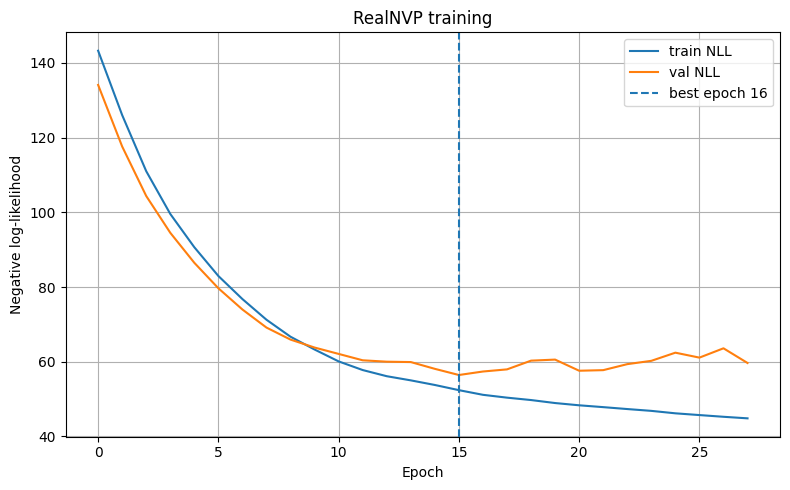

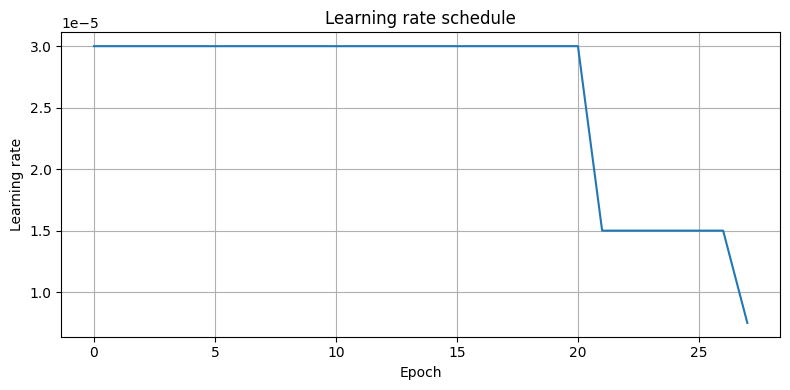

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train NLL")
plt.plot(val_history, label="val NLL")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.title("RealNVP training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_lr_schedule.png", dpi=200)
plt.show()

## 10. Calcolo anomaly score

In [12]:
def compute_flow_scores(model, X, batch_size=4096):
    loader = DataLoader(
        AggregateDataset(X),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    logps = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            logp = model.log_prob(X_batch)
            nll = -logp

            scores.append(nll.cpu().numpy())
            logps.append(logp.cpu().numpy())

    return np.concatenate(scores), np.concatenate(logps)


scores_train, logp_train = compute_flow_scores(flow, X_train)
scores_val, logp_val = compute_flow_scores(flow, X_val)
scores_bkg_test, logp_bkg_test = compute_flow_scores(flow, X_bkg_test)
scores_sig, logp_sig = compute_flow_scores(flow, X_sig)


def print_summary(name, scores):
    print("\n", name)
    print("mean:", float(np.mean(scores)))
    print("std:", float(np.std(scores)))
    print("median:", float(np.median(scores)))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_summary("train NLL", scores_train)
print_summary("val NLL", scores_val)
print_summary("bkg_test NLL", scores_bkg_test)
print_summary("signal NLL", scores_sig)


 train NLL
mean: 51.62263107299805
std: 33.77125930786133
median: 48.1004638671875
quantiles: [  12.71503448   25.67648338   31.80490265   40.99280167   48.10046387
   56.8120575    79.66037407  113.59319801  271.73419485 3099.11083984]

 val NLL
mean: 56.45098876953125
std: 512.5677490234375
median: 48.19668197631836
quantiles: [1.36332169e+01 2.60222122e+01 3.18103939e+01 4.10753975e+01
 4.81966820e+01 5.70472622e+01 8.06808464e+01 1.18666161e+02
 4.58163967e+02 7.17050938e+04]

 bkg_test NLL
mean: 53.86384963989258
std: 148.99331665039062
median: 48.05229568481445
quantiles: [1.23424530e+01 2.63326949e+01 3.20511204e+01 4.11970100e+01
 4.80522957e+01 5.69696846e+01 8.06457943e+01 1.18000131e+02
 4.26770933e+02 1.57281064e+04]

 signal NLL
mean: 207.12664794921875
std: 4854.984375
median: 90.71725463867188
quantiles: [1.90936127e+01 3.57365506e+01 4.44925011e+01 6.47602615e+01
 9.07172585e+01 1.39472897e+02 3.39324417e+02 1.02855959e+03
 1.10218022e+04 8.02266688e+05]


## 11. Metriche: AUC, mistag, background checks

In [13]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="RealNVP"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": "NLL",
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig, model_name="RealNVP")

print("AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])


def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

AUC: 0.8758690631249999
AUC inverted: 0.124130936875
Best AUC: 0.8758690631249999
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,RealNVP,NLL,0.875869,0.875869,0.124131,False,0.300,0.300,0.857950,54.778484
1,RealNVP,NLL,0.875869,0.875869,0.124131,False,0.100,0.100,0.701800,69.232048
2,RealNVP,NLL,0.875869,0.875869,0.124131,False,0.050,0.050,0.585475,80.645798
3,RealNVP,NLL,0.875869,0.875869,0.124131,False,0.010,0.010,0.332500,118.000130
4,RealNVP,NLL,0.875869,0.875869,0.124131,False,0.001,0.001,0.034475,426.770935


,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.502993,0.497007,0.502993
1,train QCD vs test QCD,0.503340,0.496660,0.503340
2,val QCD vs test QCD,0.500349,0.499651,0.500349


## 12. ROC, score distributions, efficiency vs mistag

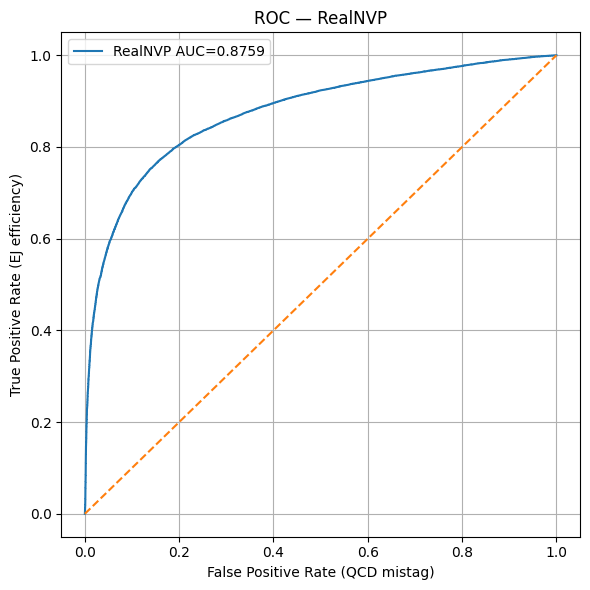

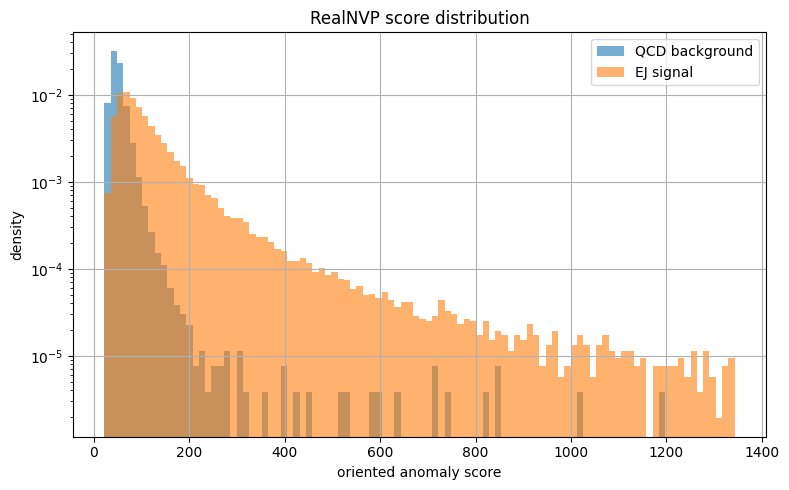

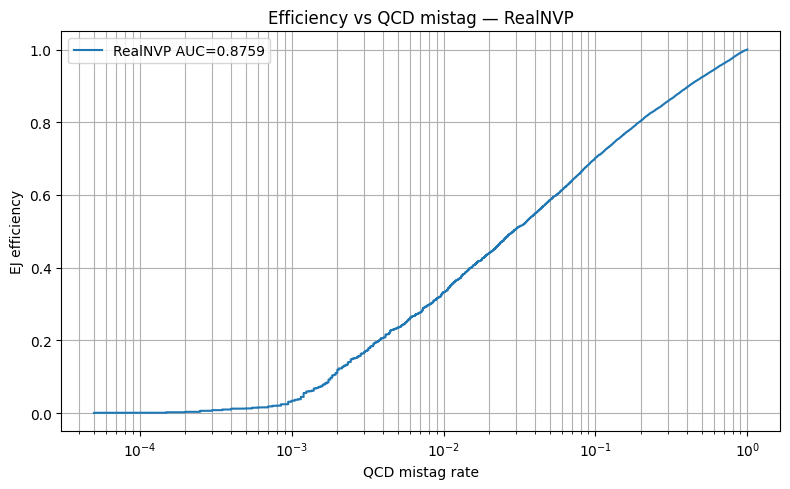

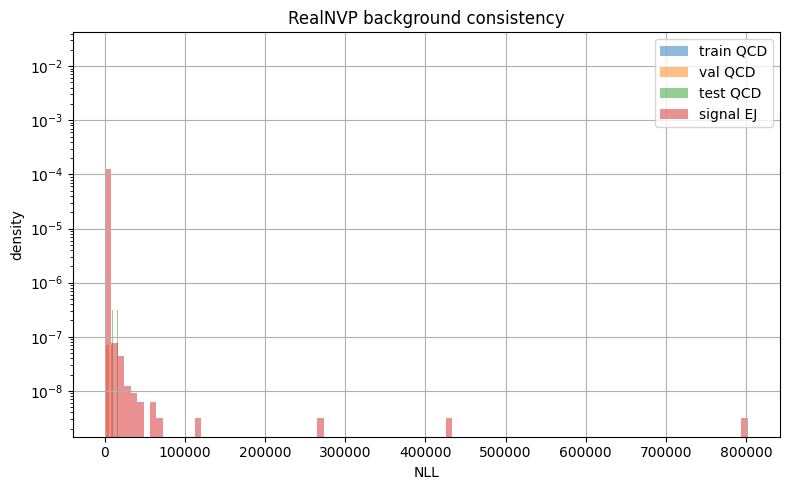

In [14]:
bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(eval_main["fpr"], eval_main["tpr"], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — RealNVP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented anomaly score")
plt.ylabel("density")
plt.title("RealNVP score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_score_distribution.png", dpi=200)
plt.show()

fpr = eval_main["fpr"]
tpr = eval_main["tpr"]
mask = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask], tpr[mask], label=f"RealNVP AUC={eval_main['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — RealNVP")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_efficiency_vs_mistag.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel("NLL")
plt.ylabel("density")
plt.title("RealNVP background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "realnvp_background_consistency.png", dpi=200)
plt.show()

## 14. Salvataggio finale

In [16]:
results_summary = {
    "model": "RealNVP",
    "score": "NLL",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "input_dim": int(input_dim),
    "n_flow_layers": int(N_FLOW_LAYERS),
    "hidden_dim": int(HIDDEN_DIM),
    "scale_clip": float(SCALE_CLIP),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "best_epoch": int(best_epoch),
    "best_val_nll": float(best_val),
    "clip_value": float(CLIP_VALUE),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "realnvp_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "aggregate_feature_names": aggregate_feature_names,
            "processed_path": str(PROCESSED_PATH),
            "scaler": scaler.state_dict(),
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(OUTPUT_DIR / "realnvp_results.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "realnvp_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": flow.state_dict(),
        "config": results_summary,
        "aggregate_feature_names": aggregate_feature_names,
        "scaler": scaler.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
    },
    OUTPUT_DIR / "realnvp_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "realnvp_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    logp_train=logp_train,
    logp_val=logp_val,
    logp_bkg_test=logp_bkg_test,
    logp_sig=logp_sig,
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "realnvp_model.pt")
print(OUTPUT_DIR / "realnvp_scores.npz")
print(OUTPUT_DIR / "realnvp_results.csv")
print(OUTPUT_DIR / "realnvp_background_checks.csv")
print(OUTPUT_DIR / "realnvp_config.json")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\normalizing_flow\realnvp_model.pt
..\outputs\normalizing_flow\realnvp_scores.npz
..\outputs\normalizing_flow\realnvp_results.csv
..\outputs\normalizing_flow\realnvp_background_checks.csv
..\outputs\normalizing_flow\realnvp_config.json
plots: ..\outputs\normalizing_flow\plots
